# 🧪 Practical Lab: Build, Clean & Visualize a Graph Network in Python

This lab walks you through the exact workflow taught in the course. You'll start with raw, flawed data, diagnose silent corruption, apply a deterministic cleaning pipeline, compute accurate metrics, and produce a reproducible visualization.

> **📦 Prerequisites**
> ```bash
> pip install networkx matplotlib pandas
> ```

---

## 🔹 Step 1: Create a Raw Graph with Intentional Flaws
**🎯 Objective:** Build a simple social network graph that contains common real-world defects (self-loops, duplicate edges, isolated nodes, missing attributes).  
**📝 What to do:** Initialize an empty `nx.Graph()`, add nodes and edges, and deliberately inject structural flaws so we can practice cleaning them later.

**💻 Code Answer:**

In [13]:
import networkx as nx

# 1. Initialize raw graph
G_raw = nx.Graph()

# 2. Add nodes (some will be isolates)
G_raw.add_nodes_from(["Alice", "Bob", "Charlie", "Diana", "Eve", "Frank"])

# 3. Add edges with intentional flaws
G_raw.add_edges_from([
    ("Alice", "Bob", {"weight": 0.8}),
    ("Bob", "Charlie", {"weight": 0.9}),
    ("Charlie", "Alice", {"weight": 0.7}),
    ("Alice", "Alice", {"weight": 1.0}),  # Self-loop
    ("Bob", "Charlie", {"weight": 0.9}),  # Duplicate edge
    ("Diana", "Eve", {"weight": 0.3}),    # Valid but weak
    ("Frank", "Frank", {"weight": 0.5}),  # Self-loop on isolate
    ("Diana", "Diana", {"weight": 0.2})   # Self-loop
])

print(f"Raw graph: {G_raw.number_of_nodes()} nodes, {G_raw.number_of_edges()} edges")

Raw graph: 6 nodes, 7 edges


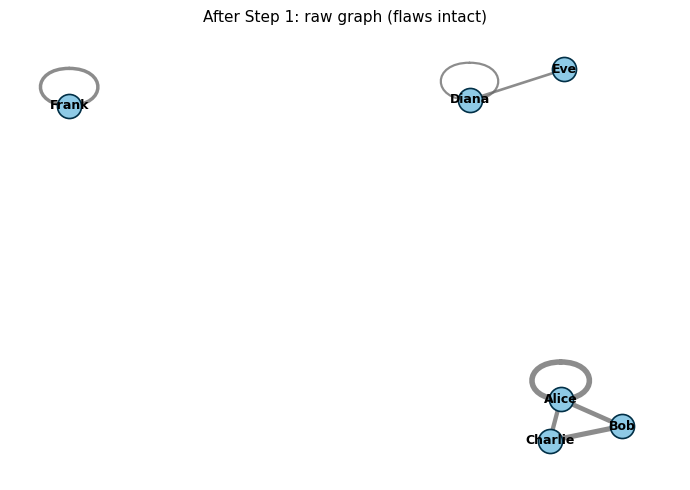

In [14]:
import matplotlib.pyplot as plt


def plot_graph_snapshot(G, title, seed=42, figsize=(7, 5)):
    """Structural snapshot; edge width scales with weight when present."""
    fig, ax = plt.subplots(figsize=figsize)
    if G.number_of_nodes() == 0:
        ax.text(0.5, 0.5, "(empty graph)", ha="center", va="center", fontsize=12)
        ax.set_title(title)
        ax.axis("off")
        plt.tight_layout()
        plt.show()
        return
    pos = nx.spring_layout(G, seed=seed)
    widths = []
    for u, v in G.edges():
        d = G[u][v]
        w = float(d.get("weight", 1.0))
        widths.append(1.0 + 3.0 * w)
    nx.draw_networkx_nodes(
        G, pos, ax=ax, node_color="#8ecae6", edgecolors="#023047", linewidths=1.2
    )
    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        width=widths if widths else 1.2,
        edge_color="#666",
        alpha=0.75,
    )
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_weight="bold")
    ax.set_title(title, fontsize=11)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


plot_graph_snapshot(G_raw, "After Step 1: raw graph (flaws intact)")

## 🔹 Step 2: Ingest Tabular Data & Attach Messy Attributes
**🎯 Objective:** Simulate loading edge data from a pandas DataFrame and attach inconsistent node attributes.  
**📝 What to do:** Create a DataFrame with source/destination/weight columns, rebuild the graph using NetworkX's pandas integration, then add node attributes with casing/spacing inconsistencies.

**💻 Code Answer:**

In [15]:
import pandas as pd

# 1. Create edge DataFrame
df = pd.DataFrame([
    {"src": "Alice", "dst": "Bob", "weight": 0.8},
    {"src": "Bob", "dst": "Charlie", "weight": 0.9},
    {"src": "Charlie", "dst": "Alice", "weight": 0.7},
    {"src": "Diana", "dst": "Eve", "weight": 0.3},
    {"src": "Alice", "dst": "Bob", "weight": 0.8},  # Duplicate
    {"src": "Frank", "dst": "Frank", "weight": 0.5}, # Self-loop
])

# 2. Build graph from DataFrame
G_df = nx.from_pandas_edgelist(df, source="src", target="dst", edge_attr="weight")

# 3. Attach messy node attributes
node_attrs = {
    "Alice": {"role": " admin ", "age": "30"},
    "alice": {"role": "ADMIN", "age": "30"},   # Casing/space mismatch
    "Bob": {"role": "user"},
    "Charlie": {"role": "user", "age": "25"},
    "Diana": {"role": "user"},
    "Eve": {"role": "user"},
    "Frank": {}  # Missing attributes
}
nx.set_node_attributes(G_df, node_attrs)

print(f"DataFrame graph: {G_df.number_of_nodes()} nodes, {G_df.number_of_edges()} edges")

DataFrame graph: 6 nodes, 5 edges


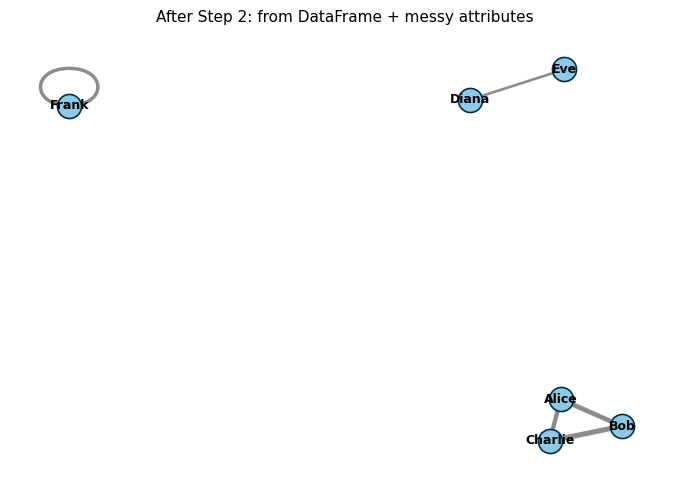

In [16]:
plot_graph_snapshot(G_df, "After Step 2: from DataFrame + messy attributes")

## 🔹 Step 3: Diagnose Before Cleaning
**🎯 Objective:** Run a systematic diagnostic to expose silent corruption.  
**📝 What to do:** Write a `diagnose_graph()` function that checks nodes, edges, self-loops, isolates, connected components, density, and missing attributes. Run it on the raw graph.

**💻 Code Answer:**

In [17]:
def diagnose_graph(G):
    print("=== 🔍 Graph Diagnostic Report ===")
    print(f"Nodes         : {G.number_of_nodes()}")
    print(f"Edges         : {G.number_of_edges()}")
    print(f"Self-loops    : {nx.number_of_selfloops(G)}")
    print(f"Isolated nodes: {len(list(nx.isolates(G)))}")
    print(f"Components    : {nx.number_connected_components(G)}")
    print(f"Is connected  : {nx.is_connected(G)}")
    print(f"Density       : {nx.density(G):.4f}\n")
    
    attrs = ["role", "age"]
    for attr in attrs:
        missing = sum(1 for n in G.nodes if attr not in G.nodes[n])
        print(f"Missing '{attr}': {missing} nodes")

# Run diagnosis
diagnose_graph(G_df)

=== 🔍 Graph Diagnostic Report ===
Nodes         : 6
Edges         : 5
Self-loops    : 1
Isolated nodes: 0
Components    : 3
Is connected  : False
Density       : 0.3333

Missing 'role': 1 nodes
Missing 'age': 4 nodes


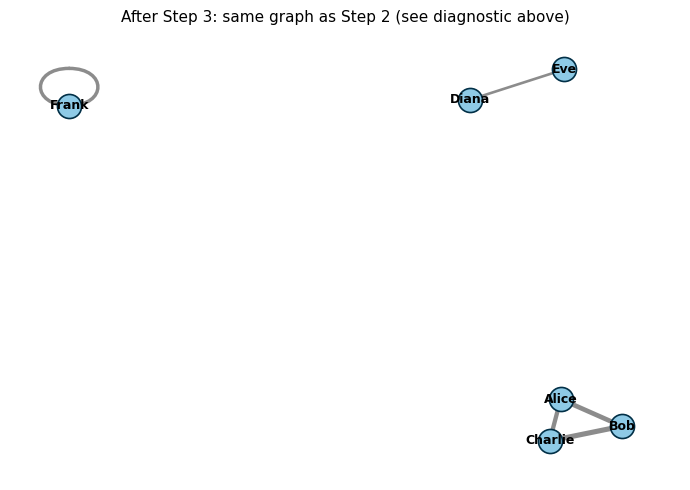

In [18]:
plot_graph_snapshot(G_df, "After Step 3: same graph as Step 2 (see diagnostic above)")

## 🔹 Step 4: Clean Edges (Self-loops & Duplicates)
**🎯 Objective:** Remove self-loops and deduplicate edges to fix degree inflation.  
**📝 What to do:** Use `nx.selfloop_edges()` to detect and remove loops. Convert to a simple `nx.Graph()` to automatically collapse duplicate edges.

**💻 Code Answer:**

In [19]:
# 1. Remove self-loops
loops = list(nx.selfloop_edges(G_df))
print(f"Removing {len(loops)} self-loops: {loops}")
G_df.remove_edges_from(nx.selfloop_edges(G_df))

# 2. Deduplicate edges (convert to simple graph)
G_clean_edges = nx.Graph(G_df)
print(f"After deduplication: {G_clean_edges.number_of_edges()} edges")

# Verify
assert nx.number_of_selfloops(G_clean_edges) == 0, "Self-loops still present!"

Removing 1 self-loops: [('Frank', 'Frank')]
After deduplication: 4 edges


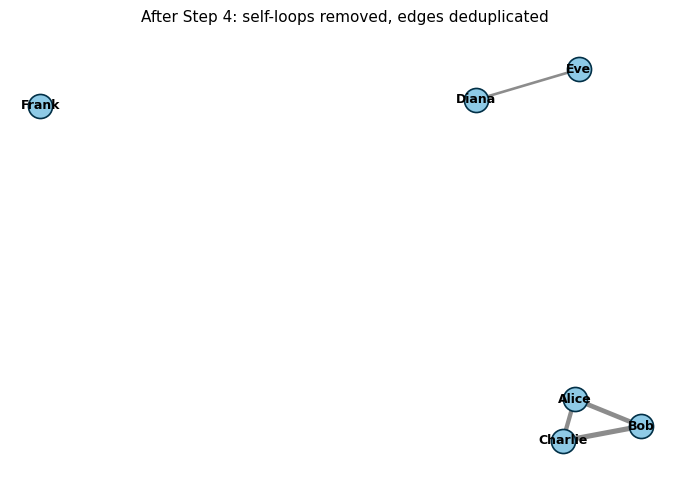

In [21]:
plot_graph_snapshot(G_clean_edges, "After Step 4: self-loops removed, edges deduplicated")

## 🔹 Step 5: Filter Weak Edges & Remove Isolates
**🎯 Objective:** Drop noise edges and zero-degree nodes that distort metrics.  
**📝 What to do:** Inspect weight distribution, remove edges below a threshold (e.g., 0.25), then prune isolated nodes.

**💻 Code Answer:**

In [22]:
# 1. Filter weak edges
threshold = 0.25
weak = [(u, v) for u, v, d in G_clean_edges.edges(data=True) 
        if d.get("weight", 1.0) < threshold]
print(f"Removing {len(weak)} weak edges (weight < {threshold})")
G_clean_edges.remove_edges_from(weak)

# 2. Remove isolated nodes
isolates = list(nx.isolates(G_clean_edges))
print(f"Removing {len(isolates)} isolated nodes: {isolates}")
G_clean_edges.remove_nodes_from(isolates)

print(f"Post-prune: {G_clean_edges.number_of_nodes()} nodes, {G_clean_edges.number_of_edges()} edges")

Removing 0 weak edges (weight < 0.25)
Removing 1 isolated nodes: ['Frank']
Post-prune: 5 nodes, 4 edges


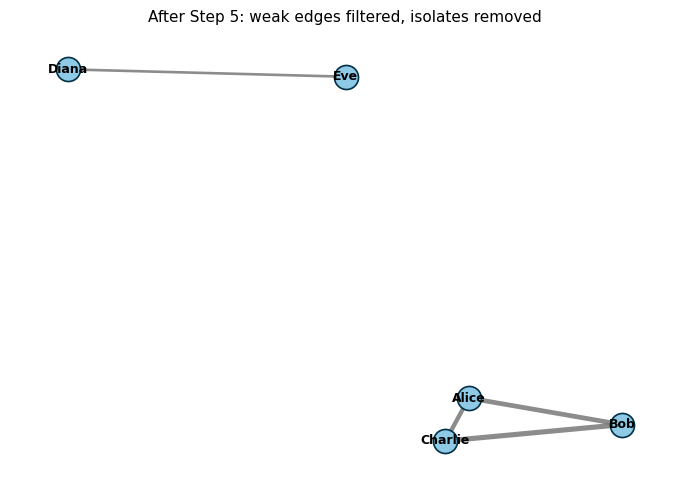

In [23]:
plot_graph_snapshot(G_clean_edges, "After Step 5: weak edges filtered, isolates removed")

## 🔹 Step 6: Extract LCC & Normalize Attributes
**🎯 Objective:** Ensure connectivity and prevent `KeyError` crashes from inconsistent labels.  
**📝 What to do:** Keep only the Largest Connected Component (LCC). Normalize string attributes (strip, lowercase) and fill missing values with defaults.

**💻 Code Answer:**

In [24]:
# 1. Extract Largest Connected Component
if not nx.is_connected(G_clean_edges):
    lcc = max(nx.connected_components(G_clean_edges), key=len)
    G_lcc = G_clean_edges.subgraph(lcc).copy()
    print(f"Extracted LCC: {G_lcc.number_of_nodes()} nodes")
else:
    G_lcc = G_clean_edges.copy()

# 2. Normalize & fill missing attributes
for n in G_lcc.nodes:
    attrs = G_lcc.nodes[n]
    # Fill defaults
    attrs.setdefault("role", "unknown")
    attrs.setdefault("age", "0")
    # Normalize strings
    if isinstance(attrs.get("role"), str):
        attrs["role"] = attrs["role"].strip().lower()
    if isinstance(attrs.get("age"), str):
        attrs["age"] = attrs["age"].strip()

print("Attributes normalized ✅")

Extracted LCC: 3 nodes
Attributes normalized ✅


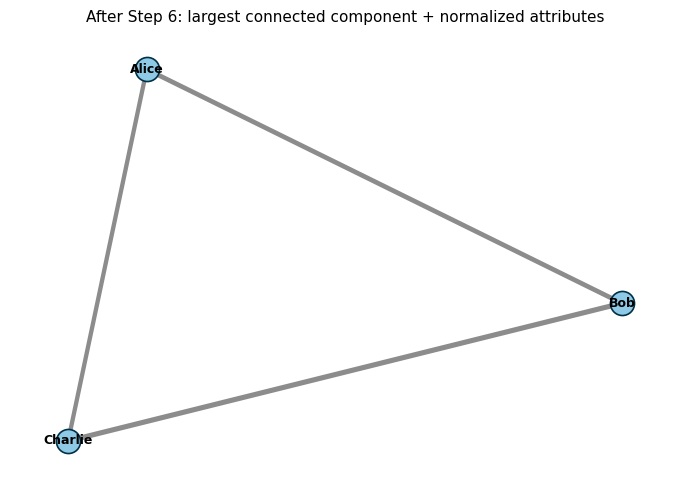

In [25]:
plot_graph_snapshot(G_lcc, "After Step 6: largest connected component + normalized attributes")

## 🔹 Step 7: Compute Metrics & Visualize Clean Graph
**🎯 Objective:** Calculate centrality metrics and render a deterministic, attribute-driven visualization.  
**📝 What to do:** Compute degree & betweenness centrality. Use `spring_layout(seed=42)` for reproducibility. Scale node size by degree, color by centrality, and render with Matplotlib.

**💻 Code Answer:**

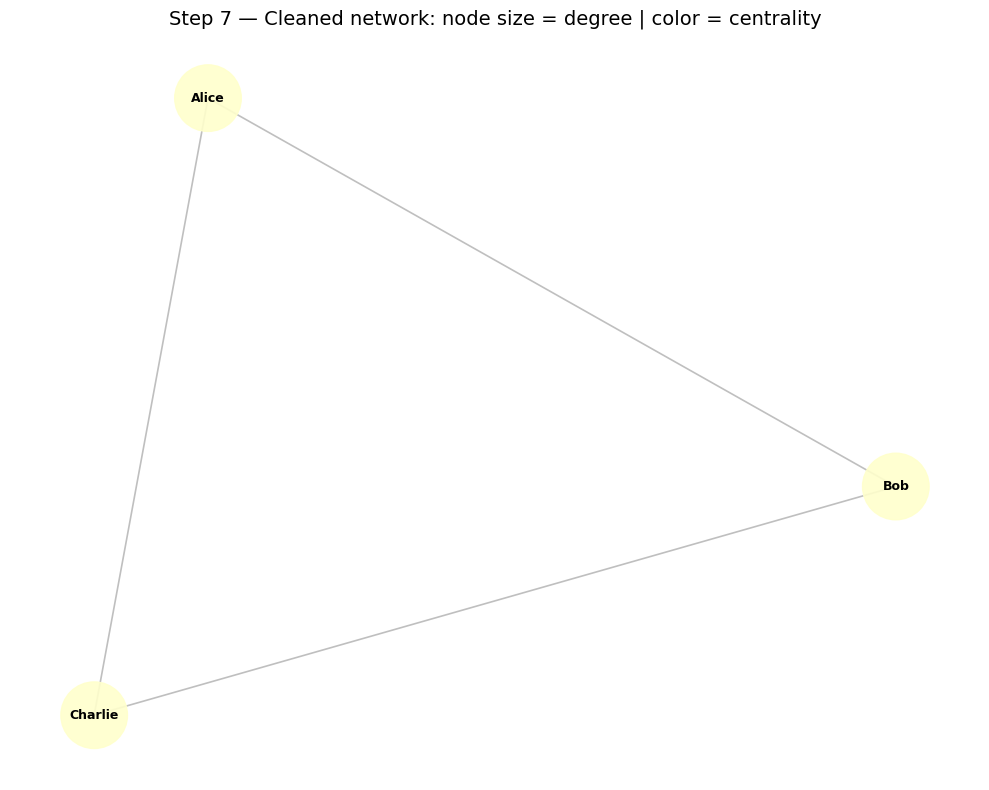

In [26]:
import matplotlib.pyplot as plt

# 1. Compute metrics
degree_cent = nx.degree_centrality(G_lcc)
between_cent = nx.betweenness_centrality(G_lcc)

# 2. Prepare visual parameters
pos = nx.spring_layout(G_lcc, seed=42)  # 🔑 Deterministic layout
node_sizes = [300 + degree_cent[n] * 2000 for n in G_lcc.nodes]
node_colors = [degree_cent[n] for n in G_lcc.nodes]

# 3. Draw
plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(G_lcc, pos, node_size=node_sizes, 
                       node_color=node_colors, cmap=plt.cm.YlOrRd, alpha=0.9)
nx.draw_networkx_edges(G_lcc, pos, edge_color="gray", alpha=0.5, width=1.2)
nx.draw_networkx_labels(G_lcc, pos, font_size=9, font_weight="bold")

plt.title(
    "Step 7 — Cleaned network: node size = degree | color = centrality",
    fontsize=14,
)
plt.axis("off")
plt.tight_layout()
plt.show()

## 📘 Lab Takeaways (Aligned with Course)
1. **Dirty graphs fail silently** → Always run `diagnose_graph()` before computing metrics.
2. **Order matters** → Self-loops → Duplicates → Weak edges → Isolates → LCC → Normalize.
3. **Reproducibility** → `seed=42` locks layouts; `G.copy()` prevents accidental mutation.
4. **Metrics = Truth** → Clean graphs yield accurate degree, betweenness, and clustering scores.
5. **Visualization encodes insight** → Size = degree, Color = centrality, Layout = structure.
